# Tutorial 15 - add_soc

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("ERROR")

In [3]:
standardized_data = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers" / "Cal_Ageing_Checkup1.xlsx"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

In [4]:
segmented_data = eet.add_primitive_segments(
    df=standardized_data,
    config=eet.PrimitiveConfig.DEFAULT,
)

In [5]:
eet.BatteryConfig.DEFAULT

_BatteryConfigClass(cell_name='Default', c_ref=4.8, soc_start=0, max_voltage=4.2, min_voltage=2.5, threshold_current=0.075, voltage_intervall=0.01, minimal_current_for_capacity=-1.2, maximal_current_for_capacity=-0.8, min_current_diff=0.5, max_time_diff=0.5, min_voltage_diff=0, ignore_negative_resistance_values=False)

## Step 1: add_soc

In [6]:
df = eet.add_soc(
    df=standardized_data,
    df_primitives=segmented_data,
    config=eet.BatteryConfig.DEFAULT,
    methods=[
        eet.SocMethod.WITHOUT_RESET,
        eet.SocMethod.WITH_RESET_WHEN_EMPTY,
        eet.SocMethod.WITH_RESET_WHEN_FULL,
        eet.SocMethod.WITH_RESET_WHEN_FULL_AND_EMPTY,
    ],
    verbose=True,
)

In [7]:
added_cols = [c for c in df.columns if c not in standardized_data.columns]
added_cols

['Capacity[Ah]',
 'SOC_WITHOUT_RESET',
 'SOC_WITH_RESET_WHEN_EMPTY',
 'SOC_WITH_RESET_WHEN_FULL',
 'SOC_WITH_RESET_WHEN_FULL_AND_EMPTY']

<div class="alert alert-block alert-warning">
<b>Warning:</b> If you're using an SOC method with reset the function will extrapolate the SOC backwards from the first reset point to deliver a better SOC estimate.
</div>

<Axes: xlabel='Test_Time[s]'>

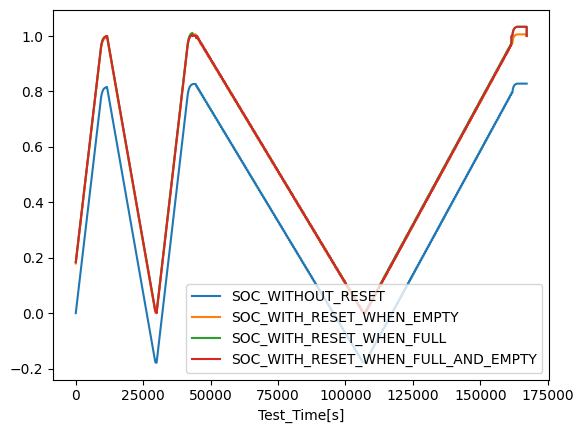

In [8]:
df.plot(x="Test_Time[s]", y=added_cols[1:])